In [1]:
# imports
import numpy as np
from typing import List, Callable
from scipy.optimize import minimize
from scipy.optimize._optimize import OptimizeResult
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp
from qiskit.primitives import StatevectorSampler, PrimitiveJob
from qiskit.circuit.library import TwoLocal
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_aer import AerSimulator

/Users/Quentin/Documents/applications/PythonIDE/path_env/quantum_env/lib/python3.8/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

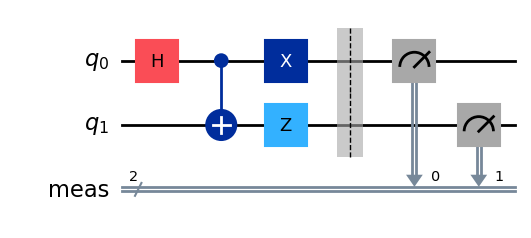

In [42]:
# Exercice 1
qc = QuantumCircuit(2)
display(Statevector(qc).draw("latex"))
qc.h(0)
qc.cx(0,1)
qc.x(0)
qc.z(1)

display(Statevector(qc).draw("latex"))

### Don't change any code past this line ###
qc.measure_all()
qc.draw('mpl')

In [43]:
# Exercice 2
sampler = StatevectorSampler()

# Start a job that will return shots for all 100 parameter value sets.
pub = qc
job_sampler = sampler.run([pub], shots=256)

result_sampler = job_sampler.result()
counts_sampler = result_sampler[0].data.meas.get_counts()

print(counts_sampler)

{'10': 135, '01': 121}


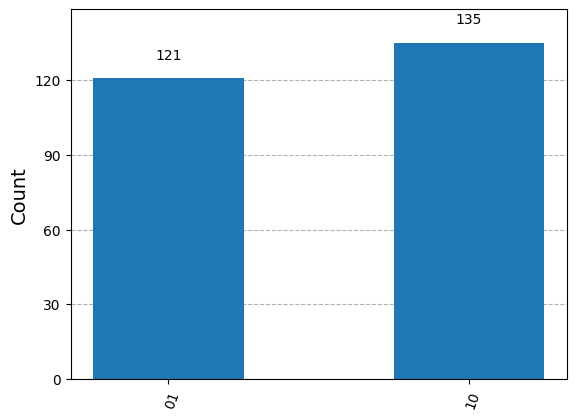

In [44]:
plot_histogram(counts_sampler)


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

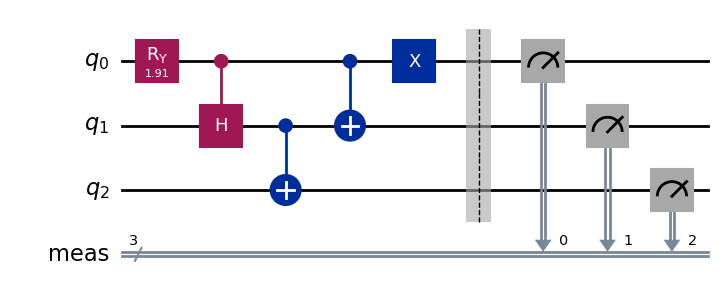

In [27]:
# Exercice 3
# Step 1
qc = QuantumCircuit(3)#your_code_here
display(Statevector(qc).draw("latex"))

# Step 2 (provided)
qc.ry(1.91063324, 0)

# Step 3: Controlled hadamard gate
qc.ch(control_qubit=0, target_qubit=1)

# Step 4: Add a CNOT gate with control qubit 1 and target qubit 2
qc.cx(control_qubit=1, target_qubit=2)

# Step 5: Add a CNOT gate with control qubit 0 and target qubit 1
qc.cx(control_qubit=0, target_qubit=1)

# Step 6: Add X gate on qubit 0
qc.x(0)

display(Statevector(qc).draw("latex"))


### Don't change any code past this line ###
qc.measure_all()
qc.draw('mpl')

In [30]:
sampler = StatevectorSampler()
pub = (qc)
job_sampler = sampler.run([pub], shots=10000)

result_sampler = job_sampler.result()
counts_sampler = result_sampler[0].data.meas.get_counts()

print(counts_sampler)

{'001': 3331, '100': 3337, '010': 3332}


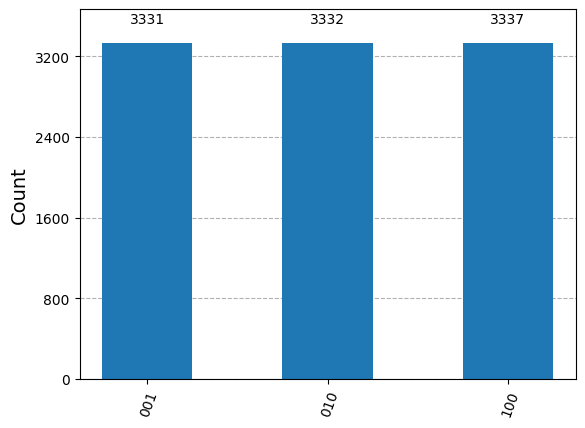

In [31]:
plot_histogram(counts_sampler)


# Part 2: VQE with Qiskit 1.0

In [39]:
# Pauli Operator 
pauli_op = SparsePauliOp(['ZII', 'IZI', 'IIZ'])
print(pauli_op.to_matrix())


[[ 3.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -3.+0.j]]


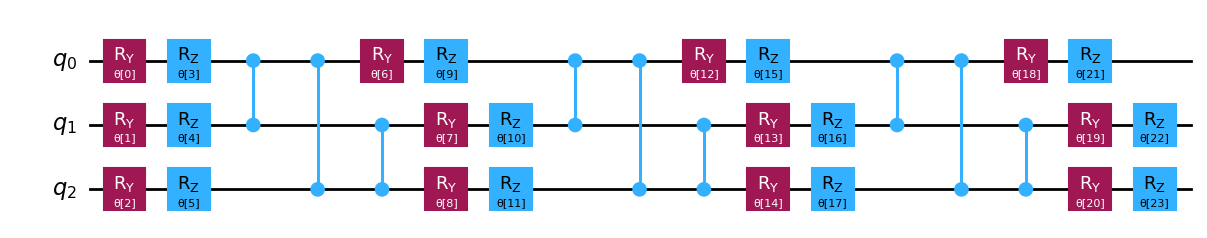

In [40]:
# Exercice 4
num_qubits = 3
rotation_blocks = ['ry', 'rz']
entanglement_blocks = 'cz'
entanglement = 'full'

ansatz = TwoLocal(num_qubits=num_qubits, rotation_blocks=rotation_blocks, 
                  entanglement_blocks=entanglement_blocks, entanglement=entanglement)

ansatz.decompose().draw("mpl")

In [45]:
num_params = ansatz.num_parameters
num_params

24

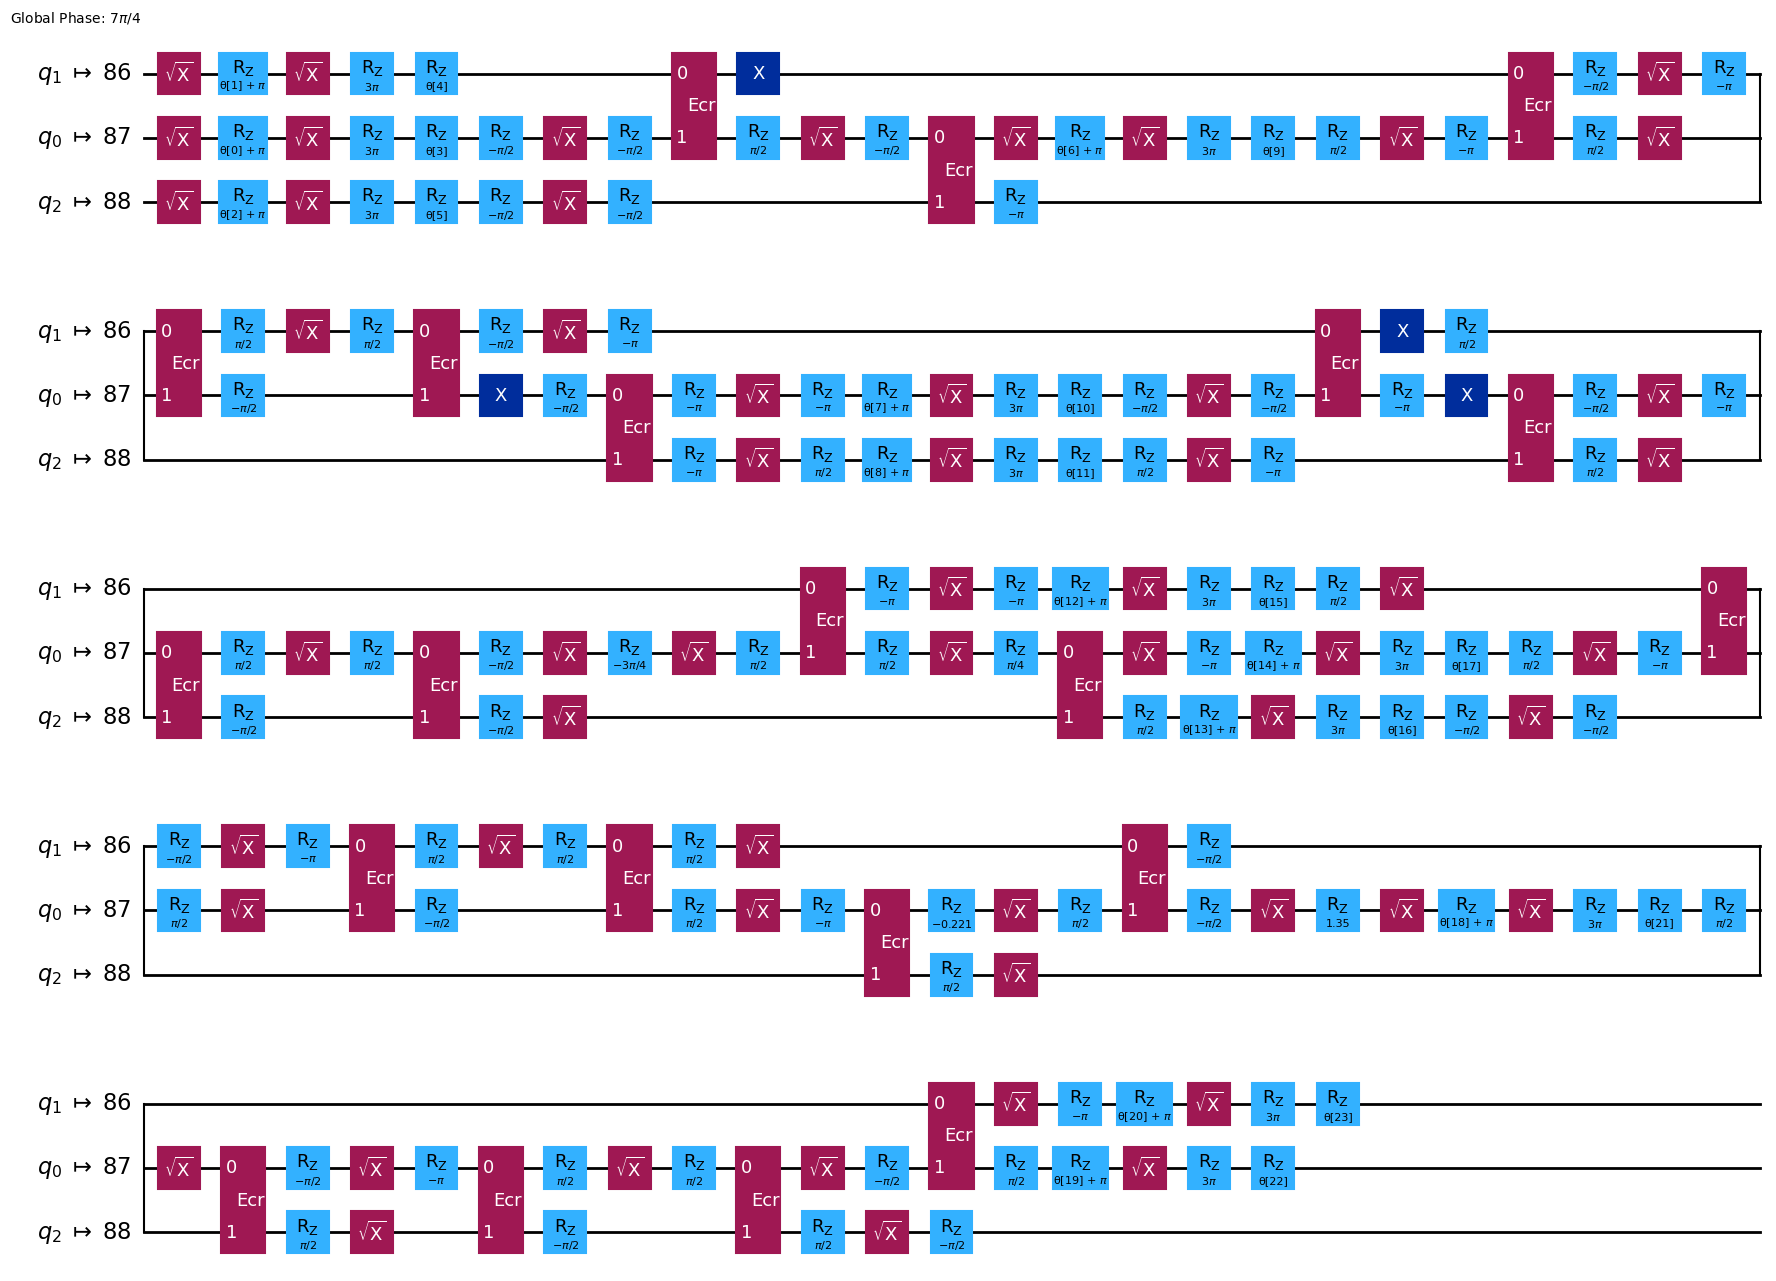

In [47]:
# Exercice 5
backend_answer = FakeSherbrooke()
optimization_level_answer = 3 # high optimization level
pm = generate_preset_pass_manager(backend=backend_answer,optimization_level=optimization_level_answer)
isa_circuit = pm.run(ansatz)
isa_circuit.draw('mpl', idle_wires=False)


In [48]:
# Define our Hamiltonian
hamiltonian_isa = pauli_op.apply_layout(layout=isa_circuit.layout)

In [86]:
# Exercice 6: defining the cost function

def cost_func(params, ansatz, hamiltonian, estimator, callback_dict):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    result = Estimator().run([pub]).result()
    energy = result[0].data.evs

    callback_dict["iters"] += 1
    callback_dict["prev_vector"] = params
    callback_dict["cost_history"].append(energy)


### Don't change any code past this line ###
    print(energy)
    return energy, result

In [50]:
callback_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

In [51]:
x0 = 2 * np.pi * np.random.random(num_params)
x0

array([4.03087182, 0.34004543, 0.2414236 , 2.41048882, 1.36845908,
       3.78836494, 3.66876496, 5.88512335, 0.56108879, 4.37667957,
       1.99422542, 3.93395249, 4.91017869, 2.19120956, 4.67648866,
       2.9606359 , 2.30861856, 2.38800448, 2.25659409, 2.30414486,
       1.83219592, 6.25274492, 3.04609065, 6.08638643])

In [89]:
# Exercice 7
### Select a Backend
## Use FakeSherbrooke to simulate with noise that matches closer to the real experiment. This will run slower.
## Use AerSimulator to simulate without noise to quickly iterate. This will run faster.

#backend = FakeSherbrooke()
backend = AerSimulator()

# ### Don't change any code past this line ###

# Here we have updated the cost function to return only the energy to be compatible with recent scipy versions (>=1.10)
def cost_func_2(*args, **kwargs):
    energy, result = cost_func(*args, **kwargs)
    return energy

with Session(backend=backend) as session:
    estimator = Estimator(mode=session)

    res = minimize(
        cost_func_2,
        x0,
        args=(isa_circuit, hamiltonian_isa, estimator, callback_dict),
        method="cobyla",
        options={'maxiter': 30})

0.4541015625
0.0673828125
0.23046875
0.5419921875
-0.02978515625
-0.24658203125
-0.3291015625
0.00048828125
-0.02978515625
-0.46484375
-0.54736328125
-0.330078125
0.05126953125
0.01123046875
-0.32666015625
-0.22998046875
-0.412109375
-0.76220703125
-0.384765625
-0.2783203125
-0.0322265625
-0.41162109375
-0.74169921875
-0.73095703125
-0.74462890625
-0.89697265625
-0.60205078125
-0.0888671875
-1.06689453125
-1.0947265625


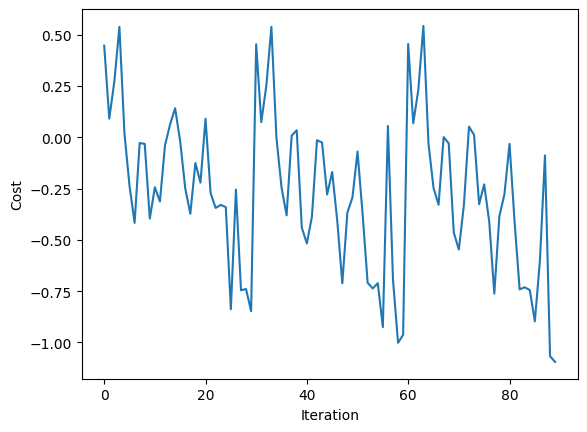

In [90]:
fig, ax = plt.subplots()
plt.plot(range(callback_dict["iters"]), callback_dict["cost_history"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.draw()